# Seaborn

## 快速上手

In [16]:
#suppress pandas future warning
#https://stackoverflow.com/a/15778297
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 修改主题分格 style: darkgrid|whitegrid|dark|white|ticks
# context: paper|notebook|talk|poster
sns.set(style = 'darkgrid', context = 'poster', font='STHeiti')
plt.rcParams['font.sans-serif'] = ['STHeiti']
plt.rcParams['axes.unicode_minus'] = False

<Axes: >

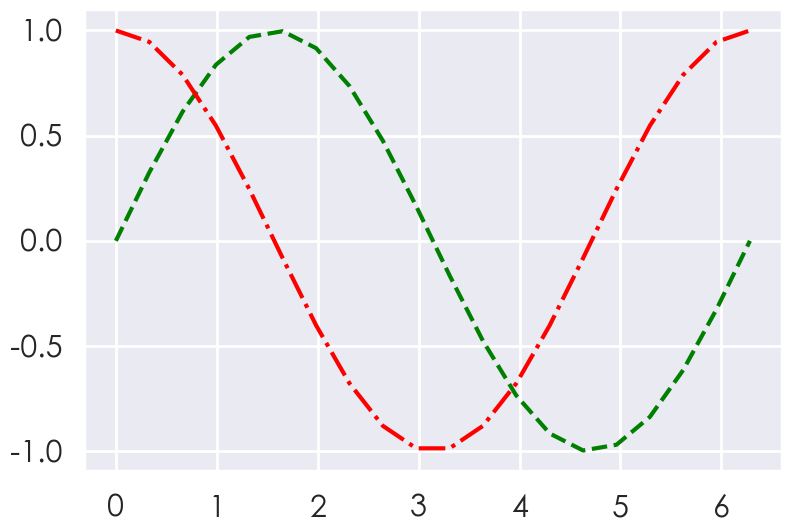

In [39]:
plt.figure(figsize = (9, 6))

x = np.linspace(0, 2 * np.pi, 20)
y = np.sin(x)

#线形图
sns.lineplot(x=x, y=y, color = 'green', ls = '--')
sns.lineplot(x=x, y=np.cos(x), color = 'red', ls = '-.')

## 各种图形绘制

### 调色板

参数 `palette` 用于修改颜色分格，默认有六种选择：`deep, muted, bright, pastel, dark, colorblind`

matplotlib 提供了更多的选择，可通过 `plt.colormaps()` 查看

### 线形图

In [43]:
plt.figure(figsize=(9,6))
fmri = pd.read_csv('./fmri.csv') # fmri这一核磁共振数据

fmri.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


<Figure size 900x600 with 0 Axes>

In [45]:
fmri['event'].unique()

array(['stim', 'cue'], dtype=object)

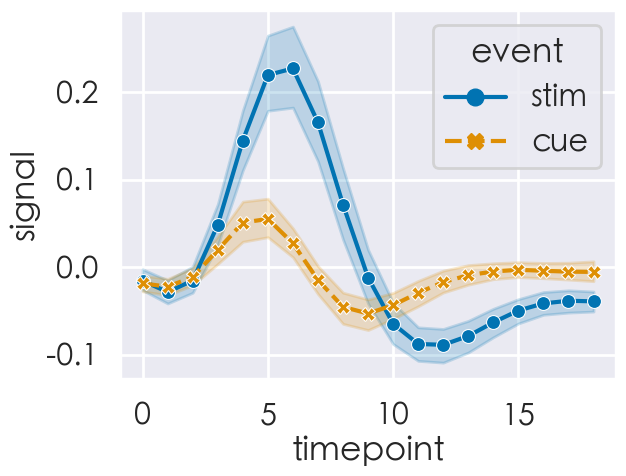

In [61]:
ax = sns.lineplot(data= fmri,
                  x = 'timepoint',#绘制 timepoint 一列
                  y = 'signal',#绘制signal一列
                  hue = 'event',#根据指定的属性即 event 进行分组
                  style = 'event' ,#根据指定的属性即 event 指定样式
                  palette='colorblind',#颜色风格
                  markers=True,
                  markersize = 10)

# plt.xlabel('时间节点',fontsize = 30)
# plt.savefig('./线形图.png',dpi = 200)

### 散点图

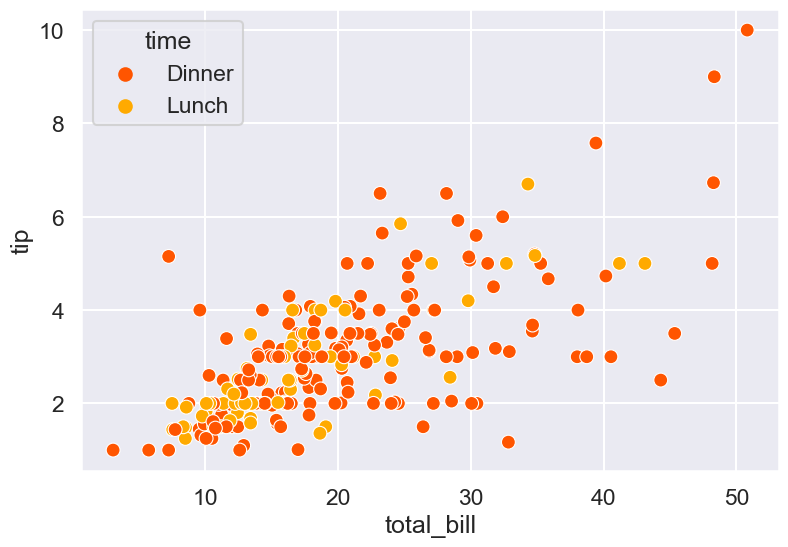

In [63]:
data = pd.read_csv('./tips.csv') # 小费

plt.figure(figsize=(9,6))
sns.set(style = 'darkgrid',context = 'talk')

# 散点图
fig = sns.scatterplot(x = 'total_bill', y = 'tip', 
                      hue = 'time', data = data, 
                      palette = 'autumn', s = 100)

### 柱状图

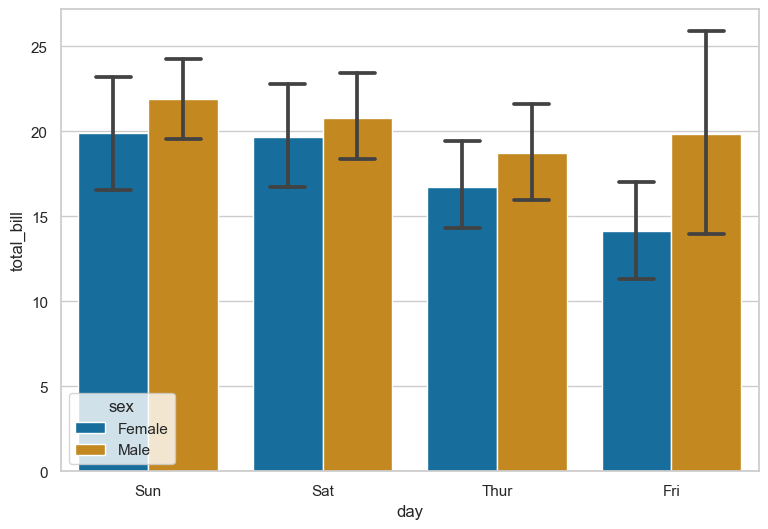

In [64]:
plt.figure(figsize = (9,6))
sns.set(style = 'whitegrid')

tips = pd.read_csv('./tips.csv') # 小费

ax = sns.barplot(x = "day", y = "total_bill", 
                 data = tips,hue = 'sex',
                 palette = 'colorblind',
                 capsize = 0.2)

### 箱式图

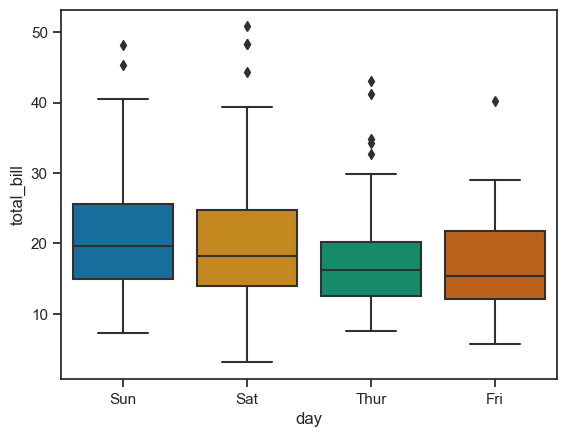

In [65]:
sns.set(style = 'ticks')
tips = pd.read_csv('./tips.csv')
ax = sns.boxplot(x="day", y="total_bill", data=tips,palette='colorblind')

### 直方图

<Axes: ylabel='Count'>

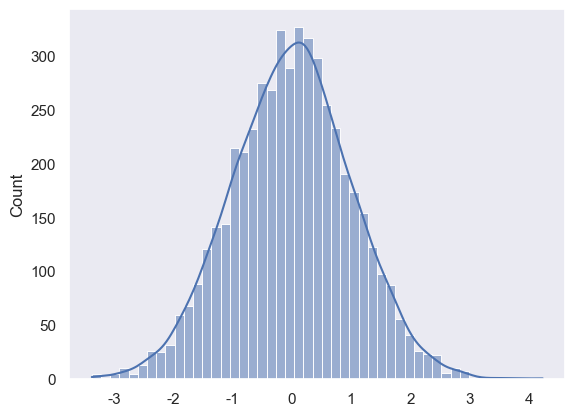

In [66]:
sns.set(style = 'dark')
x = np.random.randn(5000)
sns.histplot(x,kde = True)

<Axes: xlabel='total_bill', ylabel='Count'>

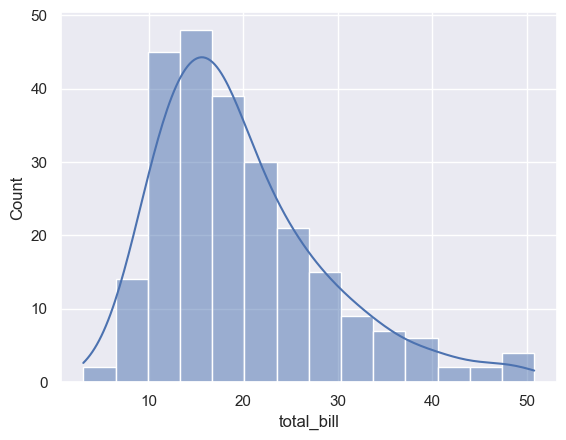

In [67]:
sns.set(style = 'darkgrid')
tips = pd.read_csv('./tips.csv')
sns.histplot(x = 'total_bill', data = tips, kde = True)

### 分类散点图

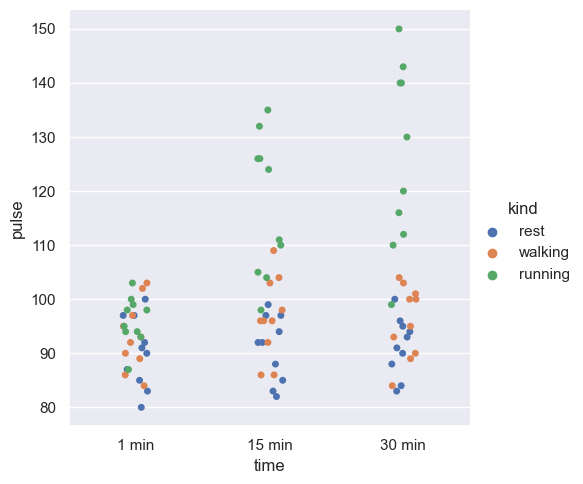

In [68]:
sns.set(style = 'darkgrid')
exercise = pd.read_csv('./exercise.csv')
sns.catplot(x="time", y="pulse", hue="kind", data=exercise)

### 热力图

<Axes: xlabel='year', ylabel='month'>

<Figure size 1200x900 with 0 Axes>

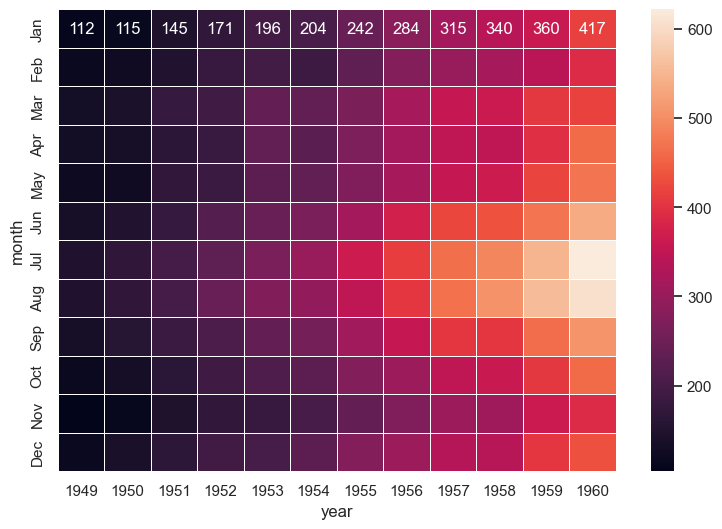

In [102]:
plt.figure(figsize=(12,9))

flights = sns.load_dataset("flights")

# 数据透视
flights = (
    flights
    .pivot(index="month", columns="year", values="passengers")
)

f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(flights, annot=True, fmt="d", linewidths=.5, ax=ax)